In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

csv = 'dense'

encodings_csv = '../encodings/normalized_encodings_' + csv + '.csv'
features_csv = '../node_features.csv'

encodings = pd.read_csv(encodings_csv)
features = pd.read_csv(features_csv)
encodings.columns = ['identifier'] + list(encodings.columns[1:])
features.columns = ['identifier'] + list(features.columns[1:])
encodings = encodings.dropna(axis='index')
matching_ids = set(encodings['identifier']) & set(features['identifier'])

encodings = encodings[encodings['identifier'].isin(matching_ids)]
encodings = encodings.sort_values('identifier').reset_index(drop=True)
features = features[features['identifier'].isin(matching_ids)]
features = features.sort_values('identifier').reset_index(drop=True)

encodings = pd.DataFrame(normalize(encodings.iloc[:, 1:], 'l2', axis=1))

127


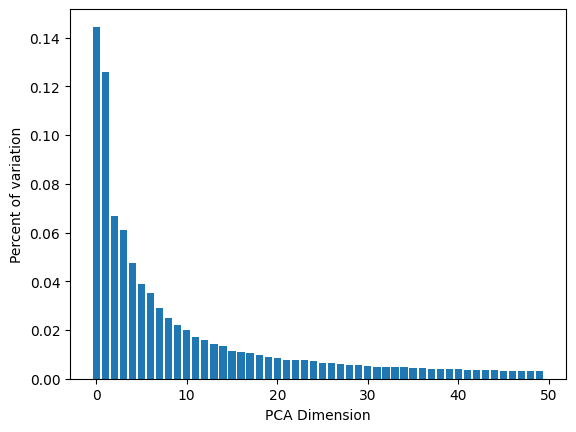

In [78]:
from sklearn.decomposition import PCA
pca = PCA(n_components='mle')
W_pca = pca.fit_transform(encodings)
variance = pca.explained_variance_ratio_
print(pca.n_components_)
plt.figure()
plt.ylabel("Percent of variation")
plt.xlabel("PCA Dimension")
plt.bar(list(range(50)), variance[:50])
plt.show()


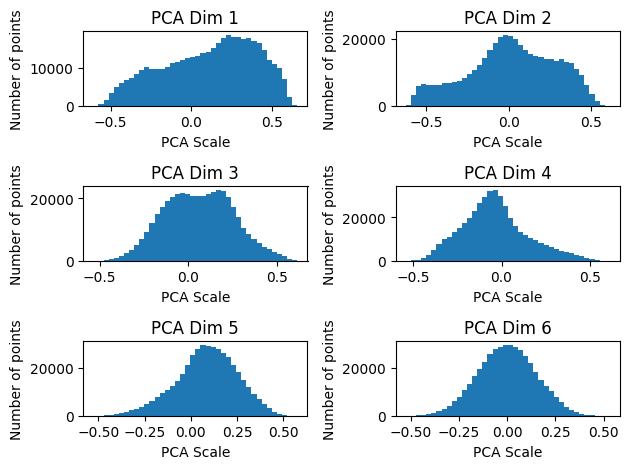

In [79]:
fig, axs = plt.subplots(3, 2)
axs = axs.flatten()
for i in range(6):
    basis_dim = pca.components_[i, :]
    scale = encodings @ basis_dim / (basis_dim @ basis_dim)
    axs[i].hist(scale, bins=40)
    axs[i].set_title(f"PCA Dim {i + 1}")
    axs[i].set_xlabel("PCA Scale")
    axs[i].set_ylabel("Number of points")
fig.tight_layout()

In [86]:
basis_dim = pca.components_[2, :]
origin = encodings.mean(axis=0)
point = origin + 0.2*basis_dim
point.to_csv('point.csv')


In [ ]:
feature = 'ASA'
characteristic = 0.90
res_labels = features.index[features[feature] > characteristic]
ASA_encodings = encodings.loc[res_labels]
high_mean = ASA_encodings.mean(axis=0)

characteristic = 0.10
res_labels = features.index[features[feature] < characteristic]
low_ASA_encodings = encodings.loc[res_labels]
low_mean = low_ASA_encodings.mean(axis=0)

ASA_basis_dim = -0.5*(high_mean - low_mean)

In [ ]:
feature = 'sec_struct'
characteristic = 'E'
res_labels = features.index[features[feature] == characteristic]
yes_SS_encodings = encodings.loc[res_labels]
stdv = yes_SS_encodings.std(axis=0)
high_mean = yes_SS_encodings.mean(axis=0)

res_labels = features.index[features[feature] != characteristic]
not_SS_encodings = encodings.loc[res_labels]
stdv = not_SS_encodings.std(axis=0)
low_mean = not_SS_encodings.mean(axis=0)

SS_basis_dim = 0.5*(high_mean - low_mean)

origin = encodings.mean(axis=0)
point = origin + SS_basis_dim + ASA_basis_dim
point.to_csv('point.csv')


In [4]:
'''
mask = stdv < 0.063
masked_e = encodings.loc[:, mask]
print(masked_e.shape)
#print(stdv[90:100])
#print(mean[90:100])

print(max(masked_e.mean(axis=0)))

fig, ax = plt.subplots()
im = ax.imshow(encodings.iloc[:25, 60:100], cmap='viridis')
fig.colorbar(im, ax=ax)
plt.show()

plt.figure()
plt.imshow(masked_e.iloc[:25, :100])
plt.show()

plt.figure()
plt.imshow(encodings.iloc[:25, pd.Series(np.where([stdv < 0.01])[1])[:128]])
plt.show()

plt.figure()
plt.imshow(basis_dim[:128].to_frame().T)
plt.show()

plt.hist(stdv, bins=20)
plt.show()
'''

"\nmask = stdv < 0.063\nmasked_e = encodings.loc[:, mask]\nprint(masked_e.shape)\n#print(stdv[90:100])\n#print(mean[90:100])\n\nprint(max(masked_e.mean(axis=0)))\n\nfig, ax = plt.subplots()\nim = ax.imshow(encodings.iloc[:25, 60:100], cmap='viridis')\nfig.colorbar(im, ax=ax)\nplt.show()\n\nplt.figure()\nplt.imshow(masked_e.iloc[:25, :100])\nplt.show()\n\nplt.figure()\nplt.imshow(encodings.iloc[:25, pd.Series(np.where([stdv < 0.01])[1])[:128]])\nplt.show()\n\nplt.figure()\nplt.imshow(basis_dim[:128].to_frame().T)\nplt.show()\n\nplt.hist(stdv, bins=20)\nplt.show()\n"